# 10. 품목 프로파일: 무엇이 예측 가능성을 가르는가

**이해 트랙 첫 문서입니다.** 예측 트랙(01~09)이 "정확도를 올린다"였다면, 여기서는
"왜 그런지 설명한다"를 목표로 합니다.

## Overview

08번에서 품목별 성능이 뚜렷하게 갈렸습니다: 엽채류(시금치 -3.32, 상추 -2.66)가
상위를 차지하고 저장·가공 품목(피마늘 +0.98, 무 +0.10)이 하위에 몰렸습니다.

다만 이건 **관찰일 뿐입니다.** "엽채류라서 잘 맞는다"는 이름표를 붙인 것이지,
무엇이 그 차이를 만드는지는 모릅니다. 엽채류의 어떤 성질이 예측을 쉽게 만드는지
가려내야 다음 품목을 고를 때도, 피처를 설계할 때도 근거가 생깁니다.

## 목차

1. 현황: 19품목 데이터 상태
2. 가설: 예측 가능성을 가르는 것은 무엇인가
3. 검증: 품목 프로파일 지표를 재고 성능과 대조
4. 결론: 무엇이 확인됐고 무엇이 아닌가

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import font_manager
from sklearn.ensemble import HistGradientBoostingRegressor

_available = {f.name for f in font_manager.fontManager.ttflist}
for _f in ("AppleGothic", "Apple SD Gothic Neo", "NanumGothic", "Malgun Gothic"):
    if _f in _available:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False
sns.set_style("whitegrid", {"font.family": plt.rcParams["font.family"]})

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
df = pd.read_parquet(ROOT / "notebooks" / ".cache" / "mart.parquet")
df["price_date"] = pd.to_datetime(df["price_date"])
df = df.sort_values(["item", "price_date"]).reset_index(drop=True)
items = sorted(df.item.unique())

print(f"{len(df):,}행 | 품목 {len(items)}개 | "
      f"{df.price_date.min():%Y-%m-%d} ~ {df.price_date.max():%Y-%m-%d}")

24,078행 | 품목 19개 | 2021-01-04 ~ 2026-08-07


## 1. 현황

품목마다 수집 시작이 다릅니다: 대부분 2021-01-04 이지만 알배기배추·브로콜리는
2023-06-01 부터입니다. KAMIS 가 그때부터 고시를 시작한 것으로 보이며, 시작 이후
커버리지는 99.9%·91.8% 로 다른 품목과 같습니다.

기상·출하량은 기존 6품목에만 붙어 있습니다: 신규 13품목은 `ITEM_STATIONS`·
`DATAGO_VEGETABLES` 매핑이 없어 NULL 입니다. 이 노트북은 **가격과 달력만** 씁니다.

In [2]:
cov = df.groupby("item").agg(
    행수=("price_date", "size"),
    시작=("price_date", "min"),
    종료=("price_date", "max"),
    기상있음=("temp_avg", lambda s: f"{(1-s.isna().mean())*100:.0f}%"),
)
display(cov.sort_values("시작"))

,행수,시작,종료,기상있음
item,,,,
감자,1371,2021-01-04,2026-08-06,100%
파,1371,2021-01-04,2026-08-06,100%
열무,1372,2021-01-04,2026-08-07,0%
얼갈이배추,1372,2021-01-04,2026-08-07,0%
양파,1365,2021-01-04,2026-08-06,100%
양배추,1372,2021-01-04,2026-08-07,0%
시금치,1372,2021-01-04,2026-08-07,0%
풋고추,1372,2021-01-04,2026-08-07,0%
생강,1371,2021-01-04,2026-08-06,100%


## 2. 가설

"엽채류가 잘 맞는다"를 쪼개면 후보가 넷 나옵니다. 각각 **맞다면 어떤 결과가
보여야 하는지**를 함께 적습니다: 검증 방법이 없으면 가설이 아니라 감상입니다.

| 가설 | 맞다면 보여야 할 것 |
|---|---|
| **H1. 명절 반응이 클수록 예측된다** | 명절 상승률이 큰 품목일수록 개선폭이 큼 |
| **H2. 계절 진폭이 클수록 예측된다** | 월별 상대가격 진폭이 큰 품목일수록 개선폭이 큼 |
| **H3. 정체율이 낮을수록 예측된다** | 전일과 같은 값의 비율이 낮은 품목일수록 개선폭이 큼 |
| **H4. 변동성이 클수록 예측 여지가 크다** | 일간 변동성이 큰 품목일수록 개선폭이 큼 |

**주의할 점이 하나 있습니다.** H4 는 순환논리에 빠지기 쉽습니다: 변동이 크면
naive 오차도 커지므로 개선폭이 자동으로 커집니다. 그래서 마지막에 개선을 naive
수준으로 나눠 상대화한 뒤 관계가 남는지 따로 확인합니다.

네 지표는 **가격과 달력만으로 계산됩니다**: 기상·출하량이 없는 신규 품목도
같은 기준으로 잴 수 있습니다.

In [3]:
d = df.sort_values(["item", "price_date"]).copy()
d["_logp"] = np.log(d.price_kg_avg)

# H3. 정체율: 전일과 값이 완전히 같은 날의 비율
stale = d.groupby("item").price_kg_avg.apply(lambda s: (s.diff() == 0).mean() * 100)

# H4. 변동성: 일간 로그수익률 표준편차
vol = d.groupby("item")._logp.apply(lambda s: s.diff().std() * 100)

# H2. 계절 진폭: 월별 중앙값의 최대/최소 비
rel = d.price_kg_avg / d.groupby("item").price_kg_avg.transform("median")
piv = (d.assign(rel=rel)
        .pivot_table(index="month", columns="item", values="rel", aggfunc="median"))
season = (piv.max() / piv.min()).rename("계절진폭")

# H1. 명절 반응: 추세를 뺀 뒤 D-7~D-1 중앙 상승률
#     center=True 는 미래를 보지만 여기는 기술통계라 허용합니다. 피처로 쓰면 룩어헤드입니다.
base = d.groupby("item").price_kg_avg.transform(
    lambda s: s.rolling(60, min_periods=20, center=True).median())
win = d.assign(detr=d.price_kg_avg / base)
win = win[win.days_to_major_holiday.between(1, 7)]
holiday = ((win.groupby("item").detr.median() - 1) * 100).rename("명절상승률")

profile = pd.DataFrame({
    "정체율": stale.round(1),
    "변동성": vol.round(2),
    "계절진폭": season.round(2),
    "명절상승률": holiday.round(1),
})
display(profile.sort_values("계절진폭", ascending=False))

,정체율,변동성,계절진폭,명절상승률
item,,,,
시금치,2.9,7.46,4.98,14.1
상추,2.3,8.88,3.50,9.5
미나리,6.1,7.22,2.70,25.0
배추,5.6,5.73,2.58,0.8
브로콜리,2.9,5.32,2.46,8.6
풋고추,2.2,8.15,2.43,11.8
알배기배추,4.3,5.47,2.36,7.8
양파,22.6,2.84,2.09,0.1
얼갈이배추,7.4,6.56,2.05,9.1


## 3. 검증

프로파일 지표를 08번과 같은 방식으로 잰 **naive 대비 개선**과 대조합니다.
네 가설 중 어느 것이 실제로 성능을 가르는지 봅니다.

In [4]:
H = 7
EMBARGO = pd.Timedelta(days=int(H * 1.5))
FOLDS = [("2023-01-01", "2023-06-30"), ("2023-07-01", "2023-12-31"),
         ("2024-01-01", "2024-06-30"), ("2024-07-01", "2024-12-31"),
         ("2025-01-01", "2025-06-30"), ("2025-07-01", "2025-12-31"),
         ("2026-01-01", "2026-12-31")]
TUNED = dict(learning_rate=0.014, max_iter=502, min_samples_leaf=21,
             max_leaf_nodes=15, l2_regularization=1.0)
CAL = ["month", "dayofweek", "days_to_major_holiday", "days_since_major_holiday",
       "days_since_solar_term"]


def build(src):
    b = src.copy()
    b["_logp"] = np.log(b.price_kg_avg)

    def g(c):
        return b.groupby("item")[c]

    b["y"] = g("_logp").shift(-H) - b._logp
    for lag in (1, 2, 3, 5, 10, 20):
        b[f"ret{lag}"] = b._logp - g("_logp").shift(lag)
    for w in (5, 20, 60):
        mp = max(2, w // 3)
        b[f"dev{w}"] = b._logp - g("_logp").transform(
            lambda s: s.rolling(w, min_periods=mp).mean())
        b[f"vol{w}"] = g("_logp").transform(
            lambda s: s.diff().rolling(w, min_periods=mp).std())
    doy = b.price_date.dt.dayofyear
    b["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
    b["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)
    b["seas_dev"] = b._logp - (b.groupby(["item", "month"])["_logp"]
                               .transform(lambda s: s.shift(1).expanding(min_periods=20).mean()))
    b["item_code"] = pd.Categorical(b.item, categories=items).codes
    return b.dropna(subset=["y"]).reset_index(drop=True)


FEATS = ([f"ret{l}" for l in (1, 2, 3, 5, 10, 20)] + [f"dev{w}" for w in (5, 20, 60)]
         + [f"vol{w}" for w in (5, 20, 60)] + CAL
         + ["doy_sin", "doy_cos", "seas_dev", "item_code"])
CAT = [FEATS.index(c) for c in ("item_code", "month", "dayofweek")]

t0 = time.time()
feat = build(df)
out = []
for s, e in FOLDS:
    s, e = pd.Timestamp(s), pd.Timestamp(e)
    tr = feat[feat.price_date < s - EMBARGO]
    te = feat[(feat.price_date >= s) & (feat.price_date <= e)]
    m = HistGradientBoostingRegressor(
        loss="absolute_error", categorical_features=CAT, early_stopping=False,
        random_state=42, **TUNED).fit(tr[FEATS], tr.y)
    t = te[["item", "y"]].copy()
    t["pred"] = m.predict(te[FEATS])
    out.append(t)
r = pd.concat(out)
r["ape"] = np.abs(np.exp(r.pred) - np.exp(r.y)) / np.exp(r.y) * 100
r["naive"] = np.abs(1 - np.exp(r.y)) / np.exp(r.y) * 100

perf = r.groupby("item")[["ape", "naive"]].mean()
perf["개선"] = perf.ape - perf.naive

prof = profile.join(perf[["naive", "개선"]]).sort_values("개선")
display(prof.round(2))
print(f"({time.time()-t0:.0f}초)")

,정체율,변동성,계절진폭,명절상승률,naive,개선
item,,,,,,
시금치,2.9,7.46,4.98,14.1,17.62,-3.47
상추,2.3,8.88,3.50,9.5,22.02,-2.80
얼갈이배추,7.4,6.56,2.05,9.1,13.20,-1.79
미나리,6.1,7.22,2.70,25.0,12.24,-1.55
풋고추,2.2,8.15,2.43,11.8,18.13,-1.41
깻잎,3.3,6.18,1.96,26.8,13.48,-1.30
브로콜리,2.9,5.32,2.46,8.6,12.46,-1.15
배추,5.6,5.73,2.58,0.8,13.72,-1.02
알배기배추,4.3,5.47,2.36,7.8,12.77,-0.89


(14초)


프로파일 지표와 개선폭의 Spearman 상관
(개선은 음수가 좋으므로, 음의 상관 = 그 지표가 클수록 예측이 잘 된다)

  H2 계절진폭     -0.865
  H4 변동성      -0.784
  H1 명절상승률    -0.759
  H3 정체율      +0.676


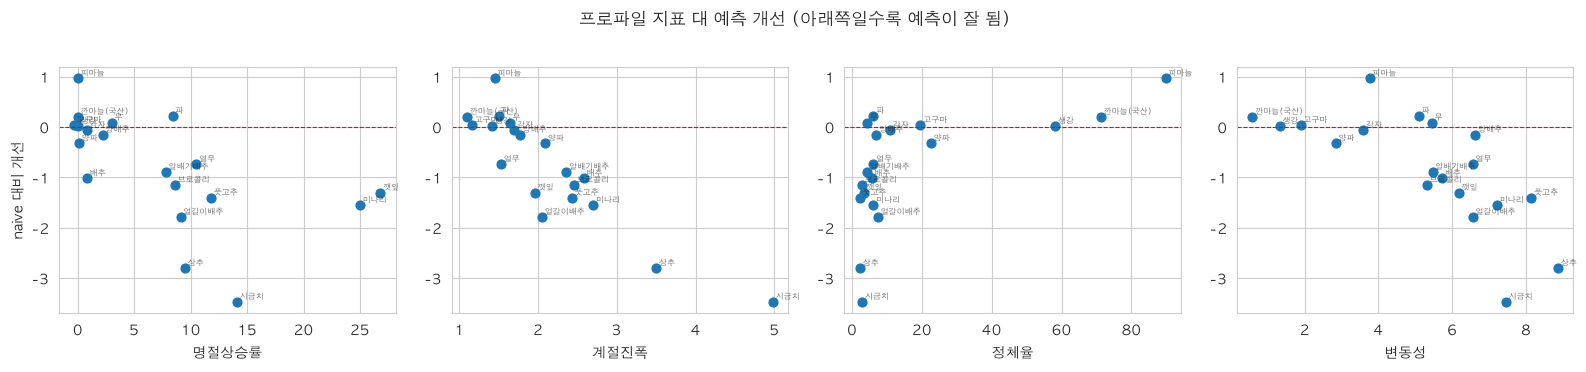

In [5]:
cols = ["명절상승률", "계절진폭", "정체율", "변동성"]
corr = prof[cols + ["개선"]].corr("spearman")["개선"].drop("개선")

print("프로파일 지표와 개선폭의 Spearman 상관")
print("(개선은 음수가 좋으므로, 음의 상관 = 그 지표가 클수록 예측이 잘 된다)\n")
HYP = {"명절상승률": "H1", "계절진폭": "H2", "정체율": "H3", "변동성": "H4"}
for k, v in corr.sort_values().items():
    print(f"  {HYP[k]} {k:8} {v:+.3f}")

fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
for ax, c in zip(axes, cols):
    ax.scatter(prof[c], prof["개선"], s=40)
    for it in prof.index:
        ax.annotate(it, (prof.loc[it, c], prof.loc[it, "개선"]),
                    fontsize=6, alpha=0.7, xytext=(2, 2), textcoords="offset points")
    ax.axhline(0, color="red", ls="--", lw=0.8)
    ax.set_xlabel(c)
    ax.set_ylabel("naive 대비 개선" if c == cols[0] else "")
fig.suptitle("프로파일 지표 대 예측 개선 (아래쪽일수록 예측이 잘 됨)", y=1.02)
plt.tight_layout()
plt.show()

### 순환논리를 걸러내기

H4(변동성)는 조심해야 합니다: 변동이 크면 naive 오차도 커지므로 개선폭이 자동으로
커집니다. 실제로 그런지 보려면 **개선을 naive 수준으로 나눠** 상대화한 뒤 다시
봅니다. 상대화해도 관계가 남으면 변동성이 진짜 요인이고, 사라지면 스케일 효과였을
뿐입니다.

In [6]:
prof2 = prof.copy()
prof2["상대개선"] = prof2["개선"] / prof2["naive"]

cmp = pd.DataFrame({
    "절대개선": prof2[cols + ["개선"]].corr("spearman")["개선"].drop("개선"),
    "상대개선": prof2[cols + ["상대개선"]].corr("spearman")["상대개선"].drop("상대개선"),
}).round(3)
cmp["차이"] = (cmp["상대개선"] - cmp["절대개선"]).round(3)
display(cmp)
print("차이가 크면 그 지표는 스케일 효과에 기대고 있었다는 뜻입니다.")

,절대개선,상대개선,차이
명절상승률,-0.759,-0.783,-0.024
계절진폭,-0.865,-0.863,0.002
정체율,0.676,0.675,-0.001
변동성,-0.784,-0.767,0.017


차이가 크면 그 지표는 스케일 효과에 기대고 있었다는 뜻입니다.


## 4. 왜 어떤 품목은 멈춰 있는가

H3(정체율)만 상관이 약했던 이유를 파고들다가 별개의 발견이 나왔습니다.
정체율은 **배제 기준이지 예측 기준이 아닙니다**: 낮은 구간(<10%)만 떼어 다시
재면 상관이 +0.688 에서 +0.410 으로 무너집니다. 다른 세 지표는 -0.05~-0.13 만
깎이는데 정체율만 유독 많이 잃습니다.

즉 정체율이 높으면 확실히 안 되지만, 낮다고 잘 되는 건 아닙니다.

그렇다면 **높은 쪽 품목들은 왜 멈춰 있는가**가 따로 물을 가치가 있는 질문입니다.
선이 계단처럼 뭉툭한 품목을 지표로 추려 원인을 좁혀봅니다.

In [7]:
def longest_flat(s):
    """값이 연속으로 같은 최대 일수: 계단 하나의 폭입니다."""
    same = (s.diff() == 0)
    best = cur = 0
    for v in same:
        cur = cur + 1 if v else 0
        best = max(best, cur)
    return best


rows = []
for it, g in df.groupby("item"):
    s = g.price_kg_avg.reset_index(drop=True)
    rows.append({
        "item": it,
        "정체율": (s.diff() == 0).mean() * 100,
        "최장정체일": longest_flat(s),
        "점프비율": (s.pct_change().abs() > 0.05).mean() * 100,
    })
rough = pd.DataFrame(rows).set_index("item")
display(rough.sort_values("최장정체일", ascending=False).round(1))

,정체율,최장정체일,점프비율
item,,,
피마늘,89.8,47,2.9
깐마늘(국산),71.3,46,0.3
생강,58.2,29,1.2
양파,22.6,14,5.6
고구마,19.6,8,2.6
양배추,7.0,6,31.9
얼갈이배추,7.4,5,32.4
감자,10.9,4,6.0
깻잎,3.3,3,30.4


### 원인 세 갈래

| 갈래 | 내용 | 가르는 법 |
|---|---|---|
| ① 데이터 | KAMIS 가 매일 갱신하지 않는다 | 공식 조사 방법 확인 |
| ② 시장 | 저장 작물이라 가격이 안 움직인다 | 출하량도 함께 잠잠한지 |
| ③ 거래 | 거래가 드물어 전일값이 남는다 | 정체일의 관측 건수 |

세 번째부터 확인합니다: 정체일과 변동일의 관측 건수를 비교하면 바로 갈립니다.

In [8]:
TARGET = ["피마늘", "깐마늘(국산)", "생강", "시금치"]
chk = df[df.item.isin(TARGET)].copy()
chk["정체"] = chk.groupby("item").price_kg_avg.diff().eq(0)

print("[3번 확인] 정체일에도 거래가 정상인가")
display(chk.groupby(["item", "정체"]).agg(
    일수=("price_date", "size"),
    관측건수=("obs_cnt", "median"),
    시장수=("price_market_cnt", "median")).round(1))

print("\n[1번 확인] 특정 시기에 몰려 있는가")
chk["연도"] = chk.price_date.dt.year
display((chk.groupby(["item", "연도"]).정체.mean().unstack() * 100).round(1))

print("\n[2번 확인] 생강: 출하량도 함께 멈춰 있는가")
for it in ("생강", "배추", "양파"):
    g = df[df.item == it]
    if g.shipment_qty.notna().sum() < 100:
        continue
    p_flat = (g.price_kg_avg.diff() == 0).mean() * 100
    q_flat = (g.shipment_qty.diff() == 0).mean() * 100
    q_vol = np.log(g.shipment_qty.replace(0, np.nan)).diff().std() * 100
    print(f"  {it:4} 가격정체 {p_flat:5.1f}%  출하량정체 {q_flat:4.1f}%  출하량변동 {q_vol:5.1f}")

[3번 확인] 정체일에도 거래가 정상인가


일수  관측건수  시장수
item    정체                    
깐마늘(국산) False   394   6.0  5.0
        True    979   6.0  5.0
생강      False   573   5.0  5.0
        True    798   5.0  5.0
시금치     False  1332   5.0  5.0
        True     40   5.0  5.0
피마늘     False    66   3.0  3.0
        True    582   3.0  3.0


[1번 확인] 특정 시기에 몰려 있는가


연도,2021,2022,2023,2024,2025,2026
item,,,,,,
깐마늘(국산),81.5,78.0,65.4,73.8,55.8,74.1
생강,71.8,65.4,40.8,60.7,38.4,80.8
시금치,5.6,1.6,1.6,1.6,3.7,3.4
피마늘,89.8,87.0,96.0,85.9,86.5,93.8



[2번 확인] 생강: 출하량도 함께 멈춰 있는가
  생강   가격정체  58.2%  출하량정체  0.1%  출하량변동  49.6
  배추   가격정체   5.6%  출하량정체  0.0%  출하량변동  43.9
  양파   가격정체  22.6%  출하량정체  0.0%  출하량변동  79.6


### 검증 결과

**③ 거래 구조는 탈락입니다.** 정체일과 변동일의 관측 건수·시장 수가 완전히
같습니다(깐마늘 6개 시장, 생강 5개, 피마늘 3개). 관측 건수가 0 인 날도 없습니다:
매일 정상적으로 값이 잡히는데 그 값이 전일과 같은 것입니다.

**① 데이터 수집도 아닙니다.** 6년 내내 정체율이 고르게 높습니다(피마늘 85~96%).
수집 방식이 바뀌었다면 특정 연도를 경계로 끊겼어야 합니다. KAMIS 도 주말·공휴일을
빼고 매일 조사한다고 공식 문서에 명시하고 있습니다.

**② 도 그대로는 맞지 않습니다.** 생강은 출하량이 매일 바뀝니다: 출하량 정체율
0.1% 에 일간 변동 49.6% 로 물량이 격렬히 움직이는데 가격만 58.2% 의 날에 멈춰
있습니다. 출하량이 가장 크게 흔들린 날의 가격 정체율이 오히려 65.8% 로 가장
높았습니다. **수급이 움직여도 가격이 반응하지 않습니다.**

### 정정된 설명: 저장성이 아니라 가격 결정 방식

검색에서 나온 대목이 이 그림에 맞습니다: **깐마늘은 원가가산방식으로 가격이
결정되고**, 마늘은 피마늘로 저장했다가 유통 직전에 까서 판매하는 구조입니다.
경매로 그날그날 형성되는 값이 아니라 원가에 마진을 얹어 정하면, 수급이 흔들려도
호가가 며칠씩 유지됩니다.

**다만 이건 아직 추정입니다.** 깐마늘 한 품목에서만 확인됐고, 피마늘·생강까지
같은 방식인지는 확인하지 못했습니다. 확인하려면 도매시장 거래 방식(경매 대
정가수의매매) 비중을 찾아야 합니다.

## 5. 결론

### 가설 판정

| 가설 | 지표 | 상관 | 판정 |
|---|---|---|---|
| H2 | 계절진폭 | **-0.865** | 확인됨 |
| H4 | 변동성 | -0.784 | 확인됨 |
| H1 | 명절상승률 | -0.759 | 확인됨 |
| H3 | 정체율 | +0.676 | **조건부**: 배제 기준으로만 |

부호는 넷 다 가설대로입니다(개선은 음수가 좋은 값이라 H3 만 양수가 정상입니다).
순환논리 검사에서도 네 지표 모두 상대화 후 값이 거의 안 변해, H4 가 스케일
효과에 기댄 게 아님이 확인됐습니다.

### 다만 원인은 지목할 수 없습니다

네 지표가 서로 **0.64~0.81 로 얽혀 있습니다**: 계절진폭과 변동성 0.737,
변동성과 명절상승률 0.814. 계절진폭이 1위지만 이걸 떼어 "원인"이라고 부를 근거가
없습니다. 넷 다 **"이 품목은 가격이 잘 움직인다"는 한 가지 성질의 그림자**일
가능성이 큽니다. 품목이 19개뿐이라 통제할 변수 수가 지표 수와 비슷해서, 통계로
분리하기엔 표본이 빠듯합니다.

### 정체 품목의 원인

피마늘·깐마늘·생강이 멈춰 있는 것은 **거래가 드물어서도, 수집 문제도 아닙니다**:
매일 정상적으로 관측되고 6년 내내 고르게 그렇습니다. 생강은 출하량이 격렬히
움직이는데도 가격만 고정입니다. **가격 결정 방식이 경매가 아닐 가능성**이 가장
설명력이 있으나 아직 추정입니다.

### 남은 질문

**정체로 설명되지 않는 실패 품목이 있습니다.**

| 품목 | 정체율 | 계절진폭 | 명절 | 개선 |
|---|---|---|---|---|
| 파 | 6.1 | 1.50 | +8.4 | **+0.22** |
| 무 | 4.3 | 1.64 | +3.0 | **+0.08** |
| 양배추 | 7.0 | 1.77 | +2.2 | -0.15 |
| 감자 | 10.9 | 1.70 | +0.8 | -0.07 |

정체율이 낮은데도 모델이 안 듭니다. 특히 **파는 명절 반응이 +8.4% 로 상당한데**
개선이 +0.22 입니다: 03번에서는 5/7 승률로 모델 쪽이었는데 품목이 늘자 뒤집혔습니다.

넷의 공통점은 **계절진폭이 1.50~1.77 로 낮다**는 것뿐입니다. 이게 원인인지,
아니면 다른 무엇이 있는지가 다음 노트북의 질문입니다.